# Group-Based Trajectory Modelling (GBTM)

This example groups Bronx crime data assigned Uber Hexagons (resolution 9) by their crime trajectories using 28-day periods.

In [1]:
from pathlib import Path
import sys
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning) # to suppress runtime on model fit print out

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

## Load the example data

The incident data include spatial unit column `UBERHEX_FID`, representing resolution 9 uber hexagaons. The hexagon GeoPackage will be used to map the resulting trajectory groups.

In [2]:
crime_file = ROOT / "crimepy" / "bronx_data.csv"
hex_file = ROOT / "crimepy" / "bronx_uberhex.gpkg"

crime = pd.read_csv(crime_file)
hexes = gpd.read_file(hex_file)

print(crime[['UBERHEX_FID', "CMPLNT_DATE_ISO", "OFNS_DESC"]].head())
print(hexes.head())

   UBERHEX_FID CMPLNT_DATE_ISO       OFNS_DESC
0          2.0      16/07/2008        BURGLARY
1          2.0      22/01/2008  FELONY ASSAULT
2          2.0      09/03/2008  FELONY ASSAULT
3          2.0      13/03/2008  FELONY ASSAULT
4          2.0      11/12/2008  FELONY ASSAULT
             index  UBERHEX_FID  \
0  892a100333bffff            1   
1  892a100a9b3ffff            2   
2  892a10014dbffff            3   
3  892a100f687ffff            4   
4  892a1018babffff            5   

                                            geometry  
0  POLYGON ((1035920.241 264007.257, 1035336.769 ...  
1  POLYGON ((1015316.577 238196.144, 1014733.45 2...  
2  POLYGON ((1026265.519 269452.627, 1025682.032 ...  
3  POLYGON ((1010746.628 232249.307, 1010163.58 2...  
4  POLYGON ((1016722.271 271042.427, 1016138.808 ...  


## Fit the trajectory model

The model groups hexagons with similar crime trajectories. This example uses the quicker simpler kmeans method and suggests a group range from 4-8.

In [3]:
# Exclude the homicide counts because the low number of incidents makes it difficult to fit a trajectory model at such small spatial scales
crime = crime[crime["OFNS_DESC"] != "MURDER & NON-NEGL. MANSLAUGHTER"].copy()

In [33]:
from crimepy.gbtm_scale import gbtm_trajectories

traj, model_selection, fitted_curves = gbtm_trajectories(
    crime,
    unit_col="UBERHEX_FID",
    date_col="CMPLNT_DATE_ISO",
    theme_col="OFNS_DESC",
    period_days=28,
    method="kmeans",
    k_range=range(4, 8),
    date_format="%d/%m/%Y",
    return_diagnostics=True,
)

In [34]:
# inspect 
print(traj.keys())
print(model_selection["ALLTHEMES"])
print(fitted_curves["ALLTHEMES"])

dict_keys(['BURGLARY', 'FELONY ASSAULT', 'GRAND LARCENY OF MOTOR VEHICLE', 'ROBBERY', 'ALLTHEMES'])
       theme  K       inertia  silhouette  selected
0  ALLTHEMES  4  10789.025537    0.215163      True
1  ALLTHEMES  5  10359.236276    0.203041     False
2  ALLTHEMES  6  10102.563980    0.133687     False
3  ALLTHEMES  7   9892.612629    0.169603     False
         theme  Group  period_index period_start  period_end  fitted_count
0    ALLTHEMES      1             0   2007-01-01  2007-01-28      0.316456
1    ALLTHEMES      1             1   2007-01-29  2007-02-25      0.286076
2    ALLTHEMES      1             2   2007-02-26  2007-03-25      0.273418
3    ALLTHEMES      1             3   2007-03-26  2007-04-22      0.273418
4    ALLTHEMES      1             4   2007-04-23  2007-05-20      0.405063
..         ...    ...           ...          ...         ...           ...
99   ALLTHEMES      4            21   2008-08-11  2008-09-07      5.446429
100  ALLTHEMES      4            22   20

## View the fitted curves

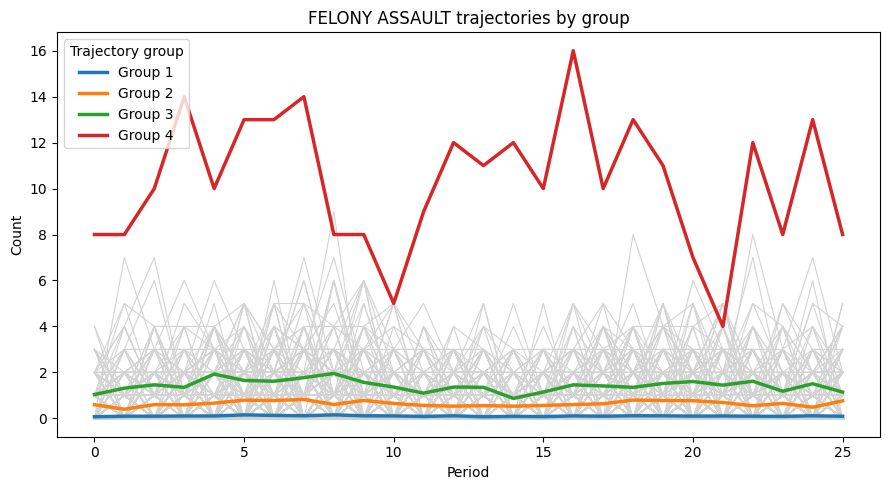

In [ ]:
# View curves for Felony Assault
theme = traj["FELONY ASSAULT"]
period_cols = [c for c in theme.columns if c.startswith("p")]
curve = fitted_curves["FELONY ASSAULT"]

fig, ax = plt.subplots(figsize=(9, 5))

# Individual hex trajectories
for _, row in theme.iterrows():
    ax.plot(
        range(len(period_cols)),
        row[period_cols].astype(float),
        color="lightgray",
        linewidth=0.8
    )

# Fitted group trajectories
for g, gcurve in curve.groupby("Group"):
    ax.plot(
        gcurve["period_index"],
        gcurve["fitted_count"],
        linewidth=2.5,
        label=f"Group {g}"
    )

ax.set_xlabel("Period")
ax.set_ylabel("Count")
ax.set_title("FELONY ASSAULT trajectories by group")
ax.legend(title="Trajectory group")

plt.tight_layout()
plt.show()

## Map the trajectory groups

The fitted trajectory groups for each spatial unit can be joined to polygon files for mapping. This can be used as a filter in downstream products.

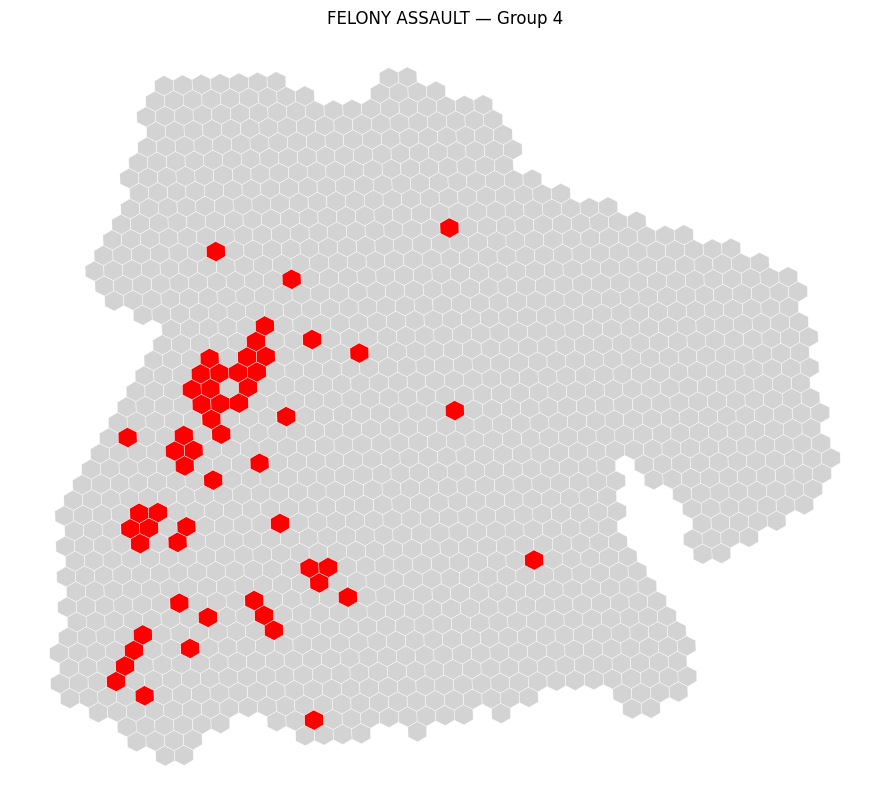

In [ ]:
# Map Felony Assault Group Locations
fig, ax = plt.subplots(figsize=(9, 9))

# Background
group_map.plot(
    color="lightgrey",
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

# Emphasise Group 4
group_map[group_map["Group"] == 4].plot(
    color="red",
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

ax.set_title("FELONY ASSAULT — Group 4")
ax.set_axis_off()

plt.tight_layout()
plt.show()